## About Model

1. "The goal of this project is to predict solar power output (AC_POWER) using environmental and system-level parameters."
2. “Given sunlight + temperature + inverter → what will be the AC power output?”
3. "Power Estimation model"

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import joblib

In [5]:
solar=pd.read_csv('Plant_1_Generation_Data.csv')
solar.head(5)

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [6]:
solar_w=pd.read_csv('Plant_1_Weather_Sensor_Data.csv')
solar_w.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [7]:
solar['DATE_TIME']=pd.to_datetime(solar['DATE_TIME'])
solar_w['DATE_TIME']=pd.to_datetime(solar_w['DATE_TIME'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_6684\390904316.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  solar['DATE_TIME']=pd.to_datetime(solar['DATE_TIME'])


In [8]:
solar.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [9]:
solar_df3=pd.merge(solar,solar_w, on='DATE_TIME', how='inner')

In [10]:
solar_df3.shape

(68774, 12)

In [11]:
solar_df3['IRRADIATION'].value_counts()

IRRADIATION
0.000000    30398
0.000039       22
0.007007       22
0.023446       22
0.041940       22
            ...  
0.000065       10
0.009817       10
0.001955       10
0.003066       10
0.008883       10
Name: count, Length: 1755, dtype: int64

In [12]:
solar_df3['IRRADIATION'].describe()

count    68774.000000
mean         0.232305
std          0.301948
min          0.000000
25%          0.000000
50%          0.031620
75%          0.454880
max          1.221652
Name: IRRADIATION, dtype: float64

In [13]:
solar_df3=solar_df3[solar_df3['IRRADIATION']>0.1]

In [14]:
solar_df3.shape

(30718, 12)

In [15]:
solar_df3=solar_df3[solar_df3['AC_POWER']>0]

In [16]:
solar_df3.shape

(30655, 12)

In [17]:
#“Due to scaled irradiation values, a performance index (power per unit irradiance) was used instead of absolute efficiency.”
Area = 1.6 # assumption
solar_df3['PERFORMANCE_INDEX']=solar_df3['AC_POWER']/(solar_df3['IRRADIATION'])

In [18]:
solar_df3.head()

,DATE_TIME,PLANT_ID_x,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,PERFORMANCE_INDEX
596,2020-05-15 07:00:00,4135001,1BY6WEcLGh8j5v7,1734.571429,170.014286,72.714286,6259631.714,4135001,HmiyD2TTLFNqkNe,24.537398,27.185653,0.14194,1197.786069
597,2020-05-15 07:00:00,4135001,1IF53ai7Xc0U56Y,1990.375000,195.100000,82.375000,6183727.375,4135001,HmiyD2TTLFNqkNe,24.537398,27.185653,0.14194,1374.520154
598,2020-05-15 07:00:00,4135001,3PZuoBAID5Wc2HD,1963.375000,192.450000,79.500000,6987838.500,4135001,HmiyD2TTLFNqkNe,24.537398,27.185653,0.14194,1355.850352
599,2020-05-15 07:00:00,4135001,7JYdWkrLSPkdwr4,1904.428571,186.700000,80.000000,7603040.000,4135001,HmiyD2TTLFNqkNe,24.537398,27.185653,0.14194,1315.340403
600,2020-05-15 07:00:00,4135001,McdE0feGgRqW7Ca,1920.250000,188.250000,80.250000,7159044.250,4135001,HmiyD2TTLFNqkNe,24.537398,27.185653,0.14194,1326.260476


In [19]:
solar_df3['PERFORMANCE_INDEX'].describe()

count    30655.000000
mean      1349.639307
std        131.449768
min         94.906054
25%       1278.060906
50%       1357.392762
75%       1429.030871
max       2764.098224
Name: PERFORMANCE_INDEX, dtype: float64

In [20]:
solar_df3[['AC_POWER','IRRADIATION','PERFORMANCE_INDEX']].head()

,AC_POWER,IRRADIATION,PERFORMANCE_INDEX
596,170.014286,0.14194,1197.786069
597,195.100000,0.14194,1374.520154
598,192.450000,0.14194,1355.850352
599,186.700000,0.14194,1315.340403
600,188.250000,0.14194,1326.260476


In [21]:
solar_df3=solar_df3.drop(columns=['DATE_TIME'])

In [22]:
solar_df3.describe()

,PLANT_ID_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,PERFORMANCE_INDEX
count,30655.0,30655.000000,30655.000000,30655.000000,3.065500e+04,30655.0,30655.000000,30655.000000,30655.000000,30655.000000
mean,4135001.0,6934.572618,678.256021,3562.547099,6.978923e+06,4135001.0,28.118505,42.736266,0.510637,1349.639307
std,0.0,3251.149795,316.802797,2467.095121,4.159015e+05,0.0,2.927551,9.624027,0.251066,131.449768
min,4135001.0,572.375000,56.162500,39.500000,6.183727e+06,4135001.0,21.432890,21.045221,0.101433,94.906054
25%,4135001.0,4191.500000,411.628571,1206.464285,6.513698e+06,4135001.0,26.116149,35.397547,0.302484,1278.060906
50%,4135001.0,6919.250000,677.437500,3512.750000,7.146394e+06,4135001.0,27.991653,43.130040,0.499473,1357.392762
75%,4135001.0,9466.133928,925.392857,5650.866072,7.268262e+06,4135001.0,30.114007,49.820072,0.700159,1429.030871
max,4135001.0,14471.125000,1410.950000,9051.285714,7.846722e+06,4135001.0,35.252486,65.545714,1.221652,2764.098224


In [23]:
solar_df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30655 entries, 596 to 68201
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   PLANT_ID_x           30655 non-null  int64  
 1   SOURCE_KEY_x         30655 non-null  object 
 2   DC_POWER             30655 non-null  float64
 3   AC_POWER             30655 non-null  float64
 4   DAILY_YIELD          30655 non-null  float64
 5   TOTAL_YIELD          30655 non-null  float64
 6   PLANT_ID_y           30655 non-null  int64  
 7   SOURCE_KEY_y         30655 non-null  object 
 8   AMBIENT_TEMPERATURE  30655 non-null  float64
 9   MODULE_TEMPERATURE   30655 non-null  float64
 10  IRRADIATION          30655 non-null  float64
 11  PERFORMANCE_INDEX    30655 non-null  float64
dtypes: float64(8), int64(2), object(2)
memory usage: 3.0+ MB


In [24]:
(solar_df3['PLANT_ID_x']==solar_df3['PLANT_ID_y']).all()

np.True_

In [25]:
(solar_df3['SOURCE_KEY_x']==solar_df3['SOURCE_KEY_y']).all()

np.False_

In [26]:
# since plantid_x and plantid_y is same for all we kwwp only plantid_x 
#for source key_y it for weather and weather is same for all so we drop it

solar_df3=solar_df3.drop(columns=['PLANT_ID_y','SOURCE_KEY_y'])

In [27]:
solar_df3=solar_df3.rename(columns={'PLANT_ID_x':'PLANT_ID','SOURCE_KEY_x':'SOURCE_KEY'})

In [28]:
solar_df3=pd.get_dummies(solar_df3, columns=['SOURCE_KEY'], drop_first=True, dtype=int)

In [29]:
solar_df3.head()

,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,PERFORMANCE_INDEX,SOURCE_KEY_1IF53ai7Xc0U56Y,...,SOURCE_KEY_iCRJl6heRkivqQ3,SOURCE_KEY_ih0vzX44oOqAx2f,SOURCE_KEY_pkci93gMrogZuBj,SOURCE_KEY_rGa61gmuvPhdLxV,SOURCE_KEY_sjndEbLyjtCKgGv,SOURCE_KEY_uHbuxQJl8lW7ozc,SOURCE_KEY_wCURE6d3bPkepu2,SOURCE_KEY_z9Y9gH1T5YWrNuG,SOURCE_KEY_zBIq5rxdHJRwDNY,SOURCE_KEY_zVJPv84UY57bAof
596,4135001,1734.571429,170.014286,72.714286,6259631.714,24.537398,27.185653,0.14194,1197.786069,0,...,0,0,0,0,0,0,0,0,0,0
597,4135001,1990.375000,195.100000,82.375000,6183727.375,24.537398,27.185653,0.14194,1374.520154,1,...,0,0,0,0,0,0,0,0,0,0
598,4135001,1963.375000,192.450000,79.500000,6987838.500,24.537398,27.185653,0.14194,1355.850352,0,...,0,0,0,0,0,0,0,0,0,0
599,4135001,1904.428571,186.700000,80.000000,7603040.000,24.537398,27.185653,0.14194,1315.340403,0,...,0,0,0,0,0,0,0,0,0,0
600,4135001,1920.250000,188.250000,80.250000,7159044.250,24.537398,27.185653,0.14194,1326.260476,0,...,0,0,0,0,0,0,0,0,0,0


## EDA

In [30]:
solar_df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30655 entries, 596 to 68201
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   PLANT_ID                    30655 non-null  int64  
 1   DC_POWER                    30655 non-null  float64
 2   AC_POWER                    30655 non-null  float64
 3   DAILY_YIELD                 30655 non-null  float64
 4   TOTAL_YIELD                 30655 non-null  float64
 5   AMBIENT_TEMPERATURE         30655 non-null  float64
 6   MODULE_TEMPERATURE          30655 non-null  float64
 7   IRRADIATION                 30655 non-null  float64
 8   PERFORMANCE_INDEX           30655 non-null  float64
 9   SOURCE_KEY_1IF53ai7Xc0U56Y  30655 non-null  int64  
 10  SOURCE_KEY_3PZuoBAID5Wc2HD  30655 non-null  int64  
 11  SOURCE_KEY_7JYdWkrLSPkdwr4  30655 non-null  int64  
 12  SOURCE_KEY_McdE0feGgRqW7Ca  30655 non-null  int64  
 13  SOURCE_KEY_VHMLBKoKgIrUVDU  30655 

In [31]:
solar_df3.describe()

,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,PERFORMANCE_INDEX,SOURCE_KEY_1IF53ai7Xc0U56Y,...,SOURCE_KEY_iCRJl6heRkivqQ3,SOURCE_KEY_ih0vzX44oOqAx2f,SOURCE_KEY_pkci93gMrogZuBj,SOURCE_KEY_rGa61gmuvPhdLxV,SOURCE_KEY_sjndEbLyjtCKgGv,SOURCE_KEY_uHbuxQJl8lW7ozc,SOURCE_KEY_wCURE6d3bPkepu2,SOURCE_KEY_z9Y9gH1T5YWrNuG,SOURCE_KEY_zBIq5rxdHJRwDNY,SOURCE_KEY_zVJPv84UY57bAof
count,30655.0,30655.000000,30655.000000,30655.000000,3.065500e+04,30655.000000,30655.000000,30655.000000,30655.000000,30655.000000,...,30655.000000,30655.000000,30655.000000,30655.000000,30655.000000,30655.000000,30655.000000,30655.000000,30655.000000,30655.000000
mean,4135001.0,6934.572618,678.256021,3562.547099,6.978923e+06,28.118505,42.736266,0.510637,1349.639307,0.045441,...,0.045572,0.045539,0.045572,0.045572,0.045474,0.045572,0.045409,0.045343,0.045474,0.045506
std,0.0,3251.149795,316.802797,2467.095121,4.159015e+05,2.927551,9.624027,0.251066,131.449768,0.208273,...,0.208558,0.208487,0.208558,0.208558,0.208344,0.208558,0.208202,0.208059,0.208344,0.208416
min,4135001.0,572.375000,56.162500,39.500000,6.183727e+06,21.432890,21.045221,0.101433,94.906054,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4135001.0,4191.500000,411.628571,1206.464285,6.513698e+06,26.116149,35.397547,0.302484,1278.060906,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4135001.0,6919.250000,677.437500,3512.750000,7.146394e+06,27.991653,43.130040,0.499473,1357.392762,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4135001.0,9466.133928,925.392857,5650.866072,7.268262e+06,30.114007,49.820072,0.700159,1429.030871,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,4135001.0,14471.125000,1410.950000,9051.285714,7.846722e+06,35.252486,65.545714,1.221652,2764.098224,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


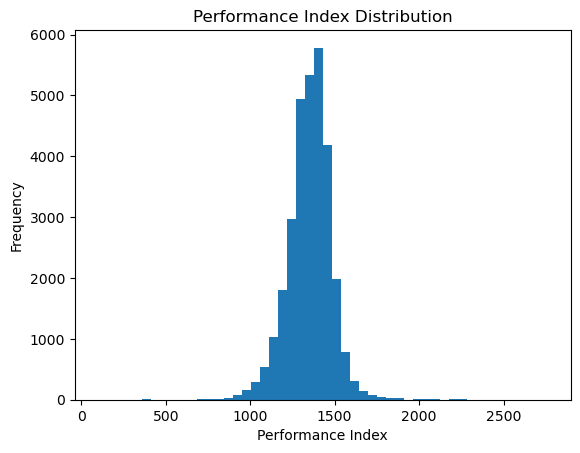

In [32]:
# Target variable analysis

plt.hist(solar_df3['PERFORMANCE_INDEX'], bins=50)
plt.title('Performance Index Distribution')
plt.xlabel('Performance Index')
plt.ylabel('Frequency')
plt.show()

#### The performance index shows an approximately normal distribution with slight right skew, indicating that most values are concentrated around the mean with few higher-value outliers.

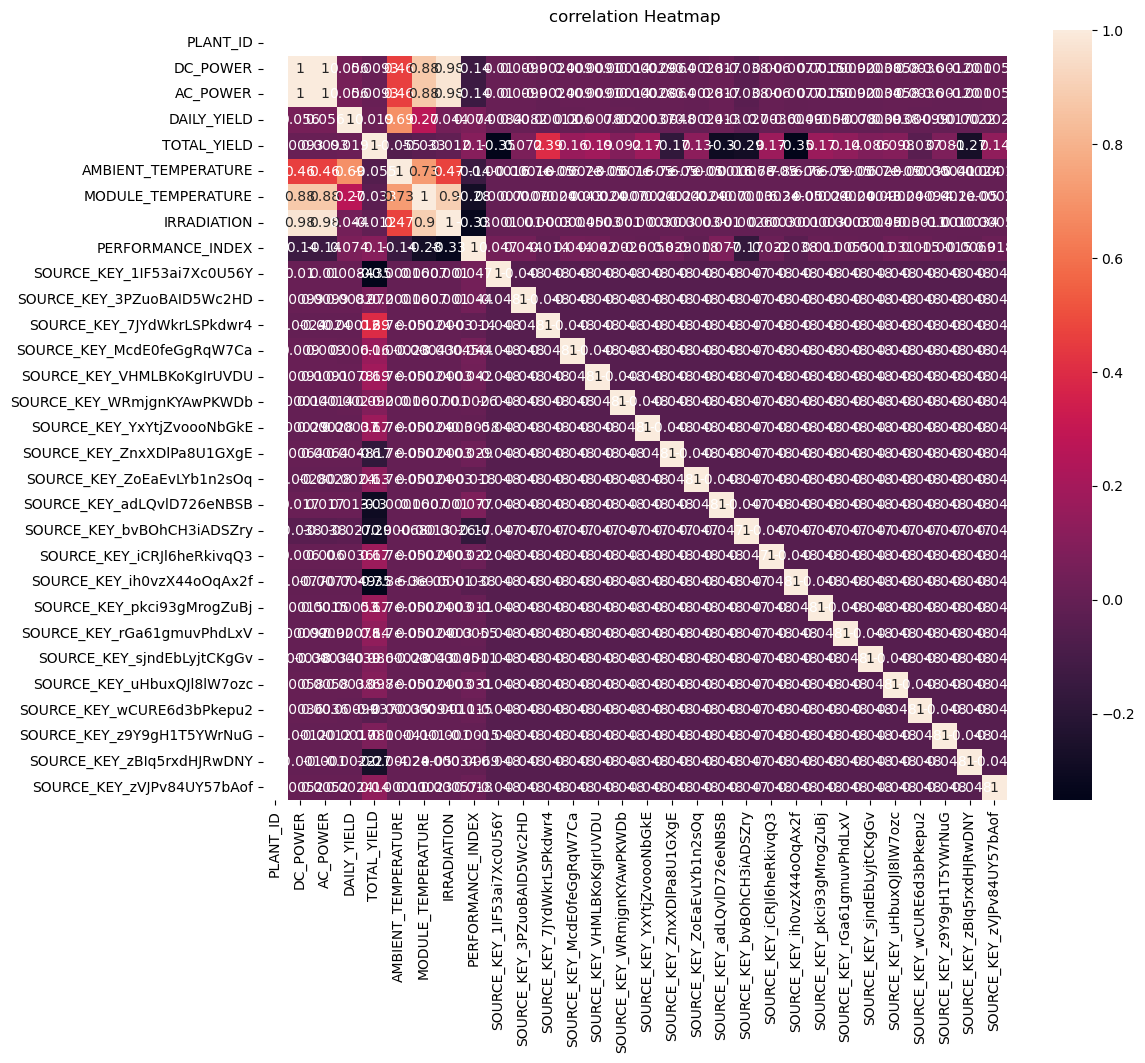

In [33]:
plt.figure(figsize=(12,10))
sns.heatmap(solar_df3.corr(), annot=True)
plt.title('correlation Heatmap')
plt.show()

In [34]:
solar_df3.corr()

,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,PERFORMANCE_INDEX,SOURCE_KEY_1IF53ai7Xc0U56Y,...,SOURCE_KEY_iCRJl6heRkivqQ3,SOURCE_KEY_ih0vzX44oOqAx2f,SOURCE_KEY_pkci93gMrogZuBj,SOURCE_KEY_rGa61gmuvPhdLxV,SOURCE_KEY_sjndEbLyjtCKgGv,SOURCE_KEY_uHbuxQJl8lW7ozc,SOURCE_KEY_wCURE6d3bPkepu2,SOURCE_KEY_z9Y9gH1T5YWrNuG,SOURCE_KEY_zBIq5rxdHJRwDNY,SOURCE_KEY_zVJPv84UY57bAof
PLANT_ID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DC_POWER,NaN,1.000000,0.999992,0.056089,0.009334,0.458807,0.877247,0.975788,-0.137603,0.010405,...,0.005996,-0.007669,0.001542,0.000924,-0.000379,0.005790,0.003628,-0.001234,-0.001010,0.005199
AC_POWER,NaN,0.999992,1.000000,0.055881,0.009328,0.458868,0.877288,0.975684,-0.137258,0.010393,...,0.005987,-0.007663,0.001536,0.000921,-0.000339,0.005783,0.003618,-0.001240,-0.001000,0.005188
DAILY_YIELD,NaN,0.056089,0.055881,1.000000,0.019170,0.690503,0.266039,0.044205,0.074478,0.008423,...,0.003563,-0.004856,0.000532,-0.000782,-0.000388,0.003770,0.000990,-0.001687,-0.002246,0.002363
TOTAL_YIELD,NaN,0.009334,0.009328,0.019170,1.000000,-0.055143,-0.033272,-0.011875,0.102306,-0.349980,...,0.171263,-0.352089,0.166019,0.135415,0.085647,0.098029,-0.036785,0.080702,-0.270207,0.138363
AMBIENT_TEMPERATURE,NaN,0.458807,0.458868,0.690503,-0.055143,1.000000,0.729097,0.467744,-0.141845,-0.000161,...,0.000067,0.000008,0.000067,0.000067,-0.000234,0.000067,-0.000346,-0.000411,-0.000237,0.000106
MODULE_TEMPERATURE,NaN,0.877247,0.877288,0.266039,-0.033272,0.729097,1.000000,0.897391,-0.282555,0.000703,...,0.000238,0.000063,0.000238,0.000238,-0.000431,0.000238,-0.000942,-0.001025,-0.000042,0.000234
IRRADIATION,NaN,0.975788,0.975684,0.044205,-0.011875,0.467744,0.897391,1.000000,-0.330882,0.001008,...,0.000301,0.000100,0.000301,0.000301,-0.000446,0.000301,-0.001060,-0.001047,0.000345,0.000568
PERFORMANCE_INDEX,NaN,-0.137603,-0.137258,0.074478,0.102306,-0.141845,-0.282555,-0.330882,1.000000,0.047373,...,0.022441,-0.038205,0.010601,0.005503,0.001143,0.030713,0.015365,-0.001477,-0.006881,0.018358
SOURCE_KEY_1IF53ai7Xc0U56Y,NaN,0.010405,0.010393,0.008423,-0.349980,-0.000161,0.000703,0.001008,0.047373,1.000000,...,-0.047676,-0.047658,-0.047676,-0.047676,-0.047622,-0.047676,-0.047586,-0.047551,-0.047622,-0.047640


### A moderate negative correlation between irradiation and performance index suggests that power output does not scale linearly with irradiance, likely due to system inefficiencies and thermal losses at higher irradiance levels.

In [35]:
solar_df3.corr()['PERFORMANCE_INDEX'].sort_values(ascending=False)

PERFORMANCE_INDEX             1.000000
TOTAL_YIELD                   0.102306
SOURCE_KEY_adLQvlD726eNBSB    0.077416
DAILY_YIELD                   0.074478
SOURCE_KEY_1IF53ai7Xc0U56Y    0.047373
SOURCE_KEY_3PZuoBAID5Wc2HD    0.044484
SOURCE_KEY_McdE0feGgRqW7Ca    0.044484
SOURCE_KEY_VHMLBKoKgIrUVDU    0.041908
SOURCE_KEY_uHbuxQJl8lW7ozc    0.030713
SOURCE_KEY_ZnxXDlPa8U1GXgE    0.028701
SOURCE_KEY_iCRJl6heRkivqQ3    0.022441
SOURCE_KEY_zVJPv84UY57bAof    0.018358
SOURCE_KEY_wCURE6d3bPkepu2    0.015365
SOURCE_KEY_pkci93gMrogZuBj    0.010601
SOURCE_KEY_rGa61gmuvPhdLxV    0.005503
SOURCE_KEY_WRmjgnKYAwPKWDb    0.002573
SOURCE_KEY_sjndEbLyjtCKgGv    0.001143
SOURCE_KEY_z9Y9gH1T5YWrNuG   -0.001477
SOURCE_KEY_YxYtjZvoooNbGkE   -0.005840
SOURCE_KEY_zBIq5rxdHJRwDNY   -0.006881
SOURCE_KEY_7JYdWkrLSPkdwr4   -0.013501
SOURCE_KEY_ZoEaEvLYb1n2sOq   -0.018117
SOURCE_KEY_ih0vzX44oOqAx2f   -0.038205
AC_POWER                     -0.137258
DC_POWER                     -0.137603
AMBIENT_TEMPERATURE      

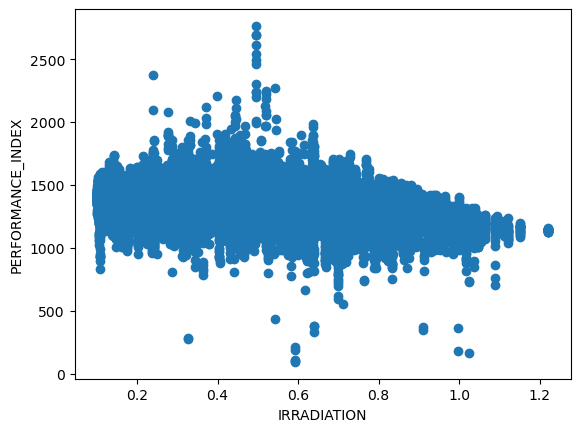

In [36]:
plt.scatter(solar_df3['IRRADIATION'],solar_df3['PERFORMANCE_INDEX'])
plt.xlabel('IRRADIATION')
plt.ylabel('PERFORMANCE_INDEX')
plt.show()

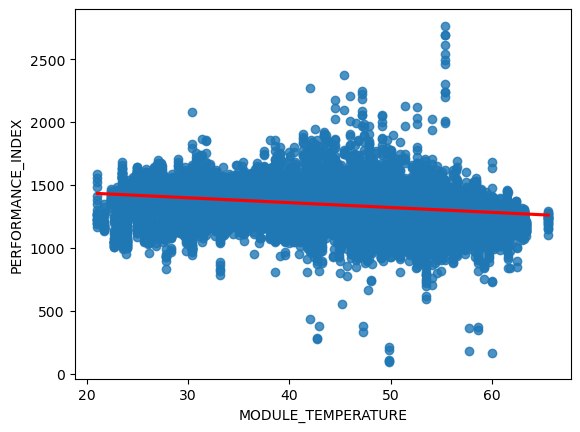

In [37]:
sns.regplot(x='MODULE_TEMPERATURE',y='PERFORMANCE_INDEX', data=solar_df3, line_kws={'color':'red'})
plt.xlabel('MODULE_TEMPERATURE')
plt.ylabel('PERFORMANCE_INDEX')
plt.show()

### A negative trend is observed between module temperature and performance index, indicating efficiency losses at higher temperatures.

In [ ]:
sns.regplot(x='AMBIENT_TEMPERATURE',y='PERFORMANCE_INDEX', data=solar_df3, line_kws={'color':'red'})
plt.xlabel('AMBIENT_TEMPERATURE')
plt.ylabel('PERFORMANCE_INDEX')
plt.show()

### A negative trend is observed between ambient temperature and performance index, indicating efficiency losses at higher temperatures.

# Observations

1. Module temperature shows a stronger negative impact compared to ambient temperature, as it directly affects the photovoltaic conversion efficiency
2. A moderate negative correlation between irradiation and performance index suggests that power output does not scale linearly with irradiance, likely due to system inefficiencies and thermal losses at higher irradiance levels.
3. At higher irradiance levels, the increase in power output is not proportional due to thermal and efficiency losses, leading to a decrease in performance index.

### Dropping the columns

1. AC_power, DC_power as they are directly related to target variable, so data leak chances are there
2. Daily_yield, Total_yield, Plant_id as they have very low correlation

In [ ]:
solar_df4=solar_df3.drop(columns=['AC_POWER', 'DC_POWER','DAILY_YIELD', 'TOTAL_YIELD', 'PLANT_ID'])

In [ ]:
solar_df4.head()

In [ ]:
solar_df4.columns

### creating x and y

In [ ]:
#model
lr=LinearRegression()

In [ ]:
X2=solar_df3.drop(columns=['AC_POWER'])
y2=solar_df3['AC_POWER']

In [ ]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [ ]:
lr.fit(X2_train, y2_train)

In [ ]:
X=X2.drop(columns=['DC_POWER','DAILY_YIELD','TOTAL_YIELD','PLANT_ID','PERFORMANCE_INDEX'])

In [ ]:
X.head()

In [ ]:
X_train, X_test, y2_train, y2_test = train_test_split(X, y2, test_size=0.2, random_state=42)

In [ ]:
lr.fit(X_train, y2_train)

In [ ]:
y_train_pred=lr.predict(X_train)
print('R2_Score_train:', r2_score(y2_train, y_train_pred))

In [ ]:
y_test_pred=lr.predict(X_test)
print('R2_Score_test2:', r2_score(y2_test, y_test_pred))

In [ ]:
solar_df3[['IRRADIATION','AC_POWER']].corr()

## AC power output shows strong dependence on irradiation, resulting in high predictive performance using environmental features.

In [ ]:
res = y2_train - y_train_pred

In [ ]:
plt.figure()
sns.distplot(res)
plt.title('Residual Plot')
plt.show()

In [ ]:
res1 = y2_test - y_test_pred

In [ ]:
plt.figure()
sns.distplot(res1)
plt.title('Residual Plot')
plt.show()

### Residual is normally distributed

In [ ]:
plt.scatter(y_test_pred, res1)

## Model Performance

1. The model achieved an R² score of approximately **0.95**, indicating strong predictive capability.
2. Solar power generation is primarily driven by irradiation, which has a strong linear relationship with AC power, allowing the model to perform well.

In [ ]:
plt.scatter(y2_test, y_test_pred)
plt.xlabel("Actual AC Power")
plt.ylabel("Predicted AC Power")
plt.title("Actual vs Predicted")
plt.show()

“The actual vs predicted plot shows a strong linear relationship, indicating that the model captures the underlying pattern effectively. Minor deviations at higher power levels suggest the presence of non-linear effects and external variations.”

In [ ]:
joblib.dump(lr, "solar_power_model.pkl")